### What Influences Wireless Speaker Purchases?

**Objectives**

This analysis explores the main factors that influence consumer purchase decisions for wireless speaker using customer review data.

**Approach**

Customer reviews are analysed to identify recurring themes in how people think about and evaluate price when buying a wireless speaker. These themes are then examined across 

age groups to understand how purchase drivers differ between consumer segments.

### Dataset Overview

The dataset used in this analysis contains reviews and demographic information related to wireless speaker purchases. Each record represents an individual respondent and qualitative feedback on factors influencing purchase decisions.

The dataset enables analysis of both what consumers say matters in their purchasing decisions and how these priorities vary across different age segments.

In particular, the dataset allows us to explore:

- What themes appear most frequently in consumer feedback

- Which product attributes influence purchase decisions

- Whether purchase drivers differ across age groups

In [1]:
# Import core libraries

import pandas as pd
import numpy as np

# Import visualisation libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Import text classifiers
import re
import nltk
import string

# warnings
import warnings
warnings.filterwarnings("ignore")


### Data Loading

In [2]:
df = pd.read_csv("../data/Customer insight review.csv")

In [3]:
df.head(5)

,Timestamp,Email Address,Do you own a wireless speaker?,How often do you use your wireless speaker?,How would you rate the sound quality of your wireless speaker?,explain the rating,How important is sound quality,How important is battery life,how important is design/Looks,"how important is connectivity options (e.g., Bluetooth, Wi-Fi)",...,Have any other lifestyle changes in the past year changed how you use wireless speakers?,How much did you spend on your wireless speaker? (US dollars),How likely are you to buy a new wireless speaker in the next 12 months?,Where do you like to buy wireless speakers?,How do you think about and evaluate the price when buying a wireless speaker?,How old are you?,What is your gender?,What's your annual household income?,"Thanks a bunch for completing our survey! Your feedback is super valuable and will help us understand what consumers want. \n\nIf you have any extra comments or feedback, please share them below.",Score
0,7/15/2024 0:17:17,fedenakashima@gmail.com,Yes,Daily,Excellent,I think it is excellent because I have nothing...,1.0,3.0,4.0,5.0,...,"More media consumption (music, movies, games)",Less than $50,1.0,"Large multi-brand stores (e.g., Amazon)",I compare it to weather it is a better option ...,18-24,Female,"More than $100,000",-,NaN
1,7/15/2024 0:21:44,victor3flores@yahoo.com,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7/15/2024 0:38:00,joycipaluz@gmail.com,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7/15/2024 21:59:16,kandacelipscomb4@gmail.com,Yes,Once a week,Good,"It’s kinda staticky, but it gets the job done (:",4.0,1.0,3.0,5.0,...,"Spending more time at home, Home workouts",$50 to $100,3.0,"Large multi-brand stores (e.g., Amazon)",I tend to go cheaper,18-24,Female,"$25,000-$50,000",NaN,NaN
4,7/15/2024 21:59:47,lailaball1@icloud.com,Yes,Daily,Excellent,It’s a Bose and it’s the best,6.0,4.0,2.0,5.0,...,"More media consumption (music, movies, games)",$100 to $200,2.0,"Large multi-brand stores (e.g., Amazon)",Usage,18-24,Female,"$50,000-$75,000",Na,NaN


In [4]:
# Create a working copy of the dataset for transformation.

df_copy = df.copy()

Given that our survey focused on the respondents who answered "Yes" to owning wireless speakers, respondents who do not own the product were filtered out.

In [5]:
# Filter out to respondents that do not own a wireless speaker.

df_copy['Do you own a wireless speaker?'].value_counts()

Do you own a wireless speaker?
Yes    3604
No     1466
Name: count, dtype: int64

Out of 5,070 respondents, approximately 71% reported owning a wireless speaker, indicating strong market penetration for wireless audio devices among surveyed consumers.

In [6]:
# Create a new DataFrame for users.

df_users = df_copy[df_copy['Do you own a wireless speaker?'] == 'Yes']

### Data Profiling & Validation

Before beginning the analysis, it is important to understand the structure and contents of the working dataset. This step helps verify the available variables, check for potential data quality issues, and identify the fields relevant to the analysis.

In [7]:
# Rename the columns

df_users = df_users.rename(columns={
'Do you own a wireless speaker?':'owns_speaker',
'How often do you use your wireless speaker?':'usage_frequency',
'How would you rate the sound quality of your wireless speaker?':'sound_quality_rating',
'explain the rating':'sound_quality_comment',
'How important is sound quality':'importance_sound_quality',
'How important is battery life':'importance_battery_life',
'how important is design/Looks':'importance_design',
'how important is connectivity options (e.g., Bluetooth, Wi-Fi)':'importance_connectivity',
'how important is durability':'importance_durability',
'how important is price':'importance_price',
'what brand do you own':'owned_brand',
'What made you buy your current wireless speaker? Recommendation from friends/family':'purchase_driver_recommendation',
'What made you buy your current wireless speaker? Online reviews from other customers ':'purchase_driver_online_reviews',
'What made you buy your current wireless speaker? Expert reviews':'purchase_driver_expert_reviews',
'What made you buy your current wireless speaker? Brand reputation':'purchase_driver_brand_reputation',
'What made you buy your current wireless speaker? Price':'purchase_driver_price',
'What made you buy your current wireless speaker? Specific features':'purchase_driver_features',
'What made you buy your current wireless speaker? Advertising':'purchase_driver_advertising',
'How happy are you with your wireless speaker?':'overall_satisfaction',
'What would make your wireless speaker better?':'improvement_suggestions',
'What do you mostly use your wireless speaker for? ':'primary_usage',
'Have any other lifestyle changes in the past year changed how you use wireless speakers? ':'lifestyle_changes_usage',
'How much did you spend on your wireless speaker? (US dollars)':'price_paid',
'How likely are you to buy a new wireless speaker in the next 12 months?':'purchase_intent',
'Where do you like to buy wireless speakers?':'purchase_channel',
'How do you think about and evaluate the price when buying a wireless speaker? ':'price_evaluation',
'How old are you?':'age',
'What is your gender?':'gender',
"What's your annual household income?":'income',
'Thanks a bunch for completing our survey! Your feedback is super valuable and will help us understand what consumers want. \n\nIf you have any extra comments or feedback, please share them below.':'additional_feedback'
})

In [8]:
df_users.columns

Index(['Timestamp', 'Email Address', 'owns_speaker', 'usage_frequency',
       'sound_quality_rating', 'sound_quality_comment',
       'importance_sound_quality', 'importance_battery_life',
       'importance_design', 'importance_connectivity', 'importance_durability',
       'importance_price', 'owned_brand', 'purchase_driver_recommendation',
       'purchase_driver_online_reviews', 'purchase_driver_expert_reviews',
       'purchase_driver_brand_reputation', 'purchase_driver_price',
       'purchase_driver_features', 'purchase_driver_advertising',
       'overall_satisfaction', 'improvement_suggestions', 'primary_usage',
       'lifestyle_changes_usage', 'price_paid', 'purchase_intent',
       'purchase_channel', 'price_evaluation', 'age', 'gender', 'income',
       'additional_feedback', 'Score'],
      dtype='str')

In [9]:
# Quick summary of column names, data types, null values.

df_users.info()

<class 'pandas.DataFrame'>
Index: 3604 entries, 0 to 5069
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Timestamp                         3604 non-null   str    
 1   Email Address                     3604 non-null   str    
 2   owns_speaker                      3604 non-null   str    
 3   usage_frequency                   3604 non-null   str    
 4   sound_quality_rating              3604 non-null   str    
 5   sound_quality_comment             3586 non-null   str    
 6   importance_sound_quality          3604 non-null   float64
 7   importance_battery_life           3604 non-null   float64
 8   importance_design                 3604 non-null   float64
 9   importance_connectivity           3604 non-null   float64
 10  importance_durability             3604 non-null   float64
 11  importance_price                  3604 non-null   float64
 12  owned_brand           

In [10]:
# Rows and columns in the dataset.

df_users.shape

(3604, 33)

In [11]:
# Total number of missing values in the dataset.

df_users.isnull().sum()

Timestamp                              0
Email Address                          0
owns_speaker                           0
usage_frequency                        0
sound_quality_rating                   0
sound_quality_comment                 18
importance_sound_quality               0
importance_battery_life                0
importance_design                      0
importance_connectivity                0
importance_durability                  0
importance_price                       0
owned_brand                            2
purchase_driver_recommendation         0
purchase_driver_online_reviews         0
purchase_driver_expert_reviews         0
purchase_driver_brand_reputation       0
purchase_driver_price                  0
purchase_driver_features               0
purchase_driver_advertising            0
overall_satisfaction                   0
improvement_suggestions               59
primary_usage                          0
lifestyle_changes_usage               68
price_paid      

In [12]:
# Check duplicates in the dataset.

duplicates = int(df_users.duplicated().sum())
duplicates

0

In [13]:
# Summary statistics for numerical columns.

df_users.describe().T

,count,mean,std,min,25%,50%,75%,max
importance_sound_quality,3604.0,3.427303,2.142052,1.0,1.0,3.0,6.0,6.0
importance_battery_life,3604.0,3.534129,1.413900,1.0,2.0,4.0,5.0,6.0
importance_design,3604.0,3.487791,1.823648,1.0,2.0,3.0,5.0,6.0
importance_connectivity,3604.0,3.534406,1.389938,1.0,3.0,4.0,4.0,6.0
importance_durability,3604.0,3.459212,1.483278,1.0,2.0,3.0,5.0,6.0
importance_price,3604.0,3.578524,1.845758,1.0,2.0,4.0,5.0,6.0
overall_satisfaction,3604.0,4.051332,0.934060,1.0,4.0,4.0,5.0,5.0
purchase_intent,3604.0,2.374584,1.316889,1.0,1.0,2.0,3.0,5.0


The mean importance scores for all features sit between **3.4** and **3.6** out of 5, suggesting owners consider all features **moderately** to **fairly important** across the board.

**Price (3.58)** and **connectivity (3.53)** rank highest in importance, while **sound quality (3.43)** ranks lowest — meaning buyers prioritise value and convenience slightly more than audio performance when making a purchase decision.

**Overall satisfaction** is high at **4.05 out of 5**, however **purchase intent** is low at **2.37 out of 5**, meaning owners are happy with their current speaker but are not looking to replace it the next 12 months.

In [14]:
# Summary statistics for text and categorical columns.

df_users.describe(include='object').T

,count,unique,top,freq
Timestamp,3604,3548,09/10/2024 6:37,3
Email Address,3604,3576,nuroag186@gmail.com,3
owns_speaker,3604,1,Yes,3604
usage_frequency,3604,5,Several times a week,1223
sound_quality_rating,3604,5,Good,1825
sound_quality_comment,3586,3217,Good,47
owned_brand,3602,683,JBL,970
purchase_driver_recommendation,3604,5,"3 (Important, but not a deal breaker)",971
purchase_driver_online_reviews,3604,5,4,989
purchase_driver_expert_reviews,3604,5,5 (Very Important),904


All 3604 respondents own a wireless speaker, with JBL being the most owned brand (970 users). Most use their speaker **several times a week** and rate their sound quality as Good.

For purchase decisions, **price** is the most important driver with 1486 rating it "Very Important", followed by **brand reputation** and **online reviews**. Advertising is the least important factor, with 1157 rating it "Not Important".

The majority of owners primarily use their speaker to listen to music, and 727 reported increased media consumption after owning one. Most owners paid **$50 to $100** for their speaker and prefer to buy from **large multi-brand online stores like Amazon**.

The typical owner is a female aged **18 to 24**, and the most common improvement suggestion is longer battery life. Income is largely undisclosed with majority preferring not to say.

In [15]:
# Drop columns not relevant to the analysis.

df_users = df_users.drop(columns=[
    'Timestamp',
    'Email Address',
    'additional_feedback',
    'Score'
])

### Exploratory Data Analysis

With the dataset structure and summary statistics established, the next step is to explore usage patterns and consumer preferences. The following visualisations analyse usage frequency, feature importance, and purchase drivers to better understand how consumers evaluate wireless speakers.

- Usage Frequency
- Feature Importance
- Purchase Factors
- Customer Satisfaction
- Budget Consideration
- Demographic Distribution

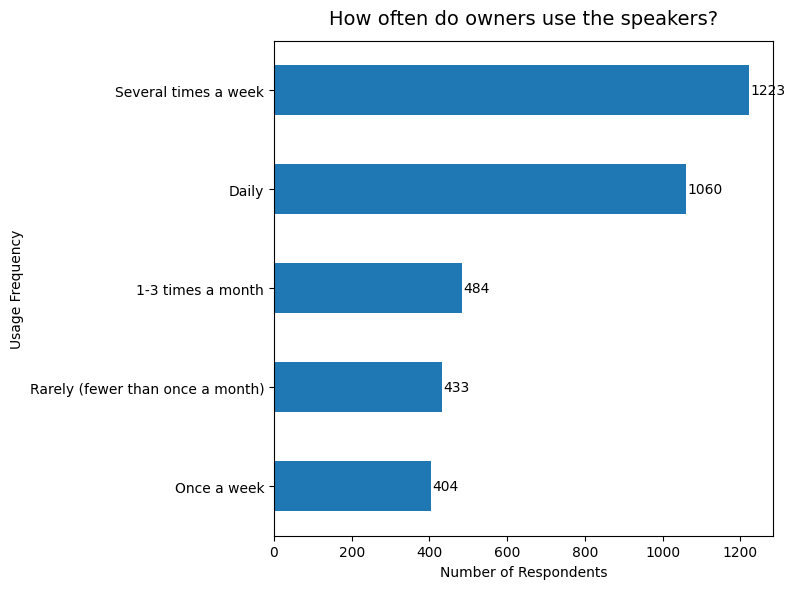

In [16]:
# graph showing usage frequency among wireless speaker owners

# Data
usage_counts = df_users['usage_frequency'].value_counts().sort_values()

# Create figure
fig, ax = plt.subplots(figsize=(8,6))

# Plot
usage_counts.plot(kind='barh', ax=ax)

# Labels
ax.set_title("How often do owners use the speakers?", fontsize=14, pad=12)
ax.set_xlabel("Number of Respondents")
ax.set_ylabel("Usage Frequency")

# Add data labels
for container in ax.containers:
    ax.bar_label(container, padding=1)

# Layout
plt.tight_layout()

plt.show()

**Insights**

Most respondents use their wireless speakers several times a week or daily, 
suggesting the product is integrated into routine entertainment and lifestyle habits.

In [17]:
# what features do owners prioritise?

importance_cols = [
'importance_sound_quality',
'importance_battery_life',
'importance_design',
'importance_connectivity',
'importance_durability',
'importance_price'
]

df_users[importance_cols].mean().sort_values(ascending=False).round(2)

importance_price            3.58
importance_connectivity     3.53
importance_battery_life     3.53
importance_design           3.49
importance_durability       3.46
importance_sound_quality    3.43
dtype: float64

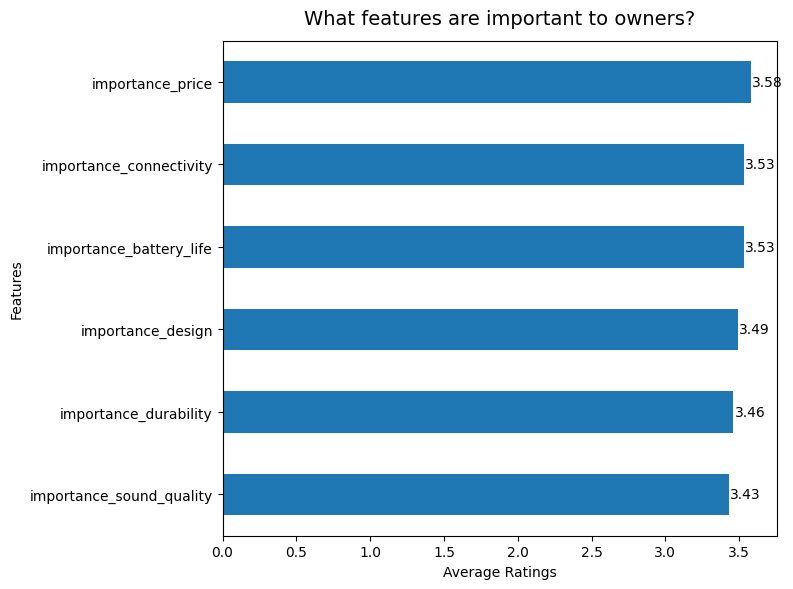

In [18]:
# visualise important features considered before purchase

# Data
importance_drivers = df_users[importance_cols].mean().sort_values(ascending=True).round(2)


# Create figure
fig, ax = plt.subplots(figsize=(8,6))

# Plot
importance_drivers.plot(kind='barh', ax=ax)

# Labels
ax.set_title("What features are important to owners?", fontsize=14, pad=12)
ax.set_xlabel("Average Ratings")
ax.set_ylabel("Features")

# Add data labels
for container in ax.containers:
    ax.bar_label(container, padding=1)

# Layout
plt.tight_layout()

plt.show()

**Insights**

Price, connectivity, and battery of the wireless speakers mattered most to the owners, while they were indifferent regarding the sound quality.

In [19]:
# What factors influenced users.

purchase_cols = [
'purchase_driver_recommendation',
'purchase_driver_online_reviews',
'purchase_driver_expert_reviews',
'purchase_driver_brand_reputation',
'purchase_driver_price',
'purchase_driver_features',
'purchase_driver_advertising'
]

df_users[purchase_cols] = df_users[purchase_cols].replace(r'^(\d).*', r'\1', regex=True).astype(float) # Use regex to eliminate the strings.

In [20]:
# What are the purchase drivers

df_users[purchase_cols].mean().sort_values(ascending=False).round(2)

purchase_driver_price               3.92
purchase_driver_brand_reputation    3.67
purchase_driver_features            3.41
purchase_driver_online_reviews      3.41
purchase_driver_expert_reviews      3.37
purchase_driver_recommendation      2.89
purchase_driver_advertising         2.42
dtype: float64

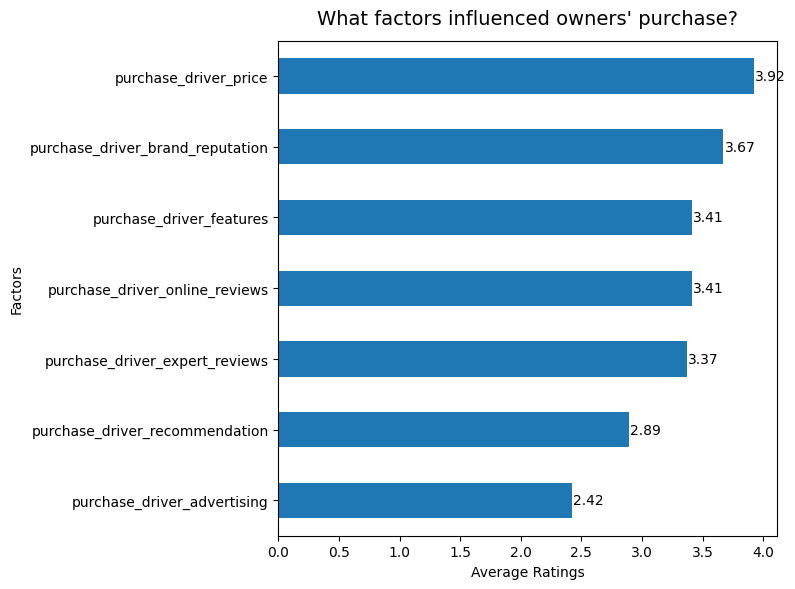

In [21]:
# Visualise the purchase driverss

# Data
purchase_drivers = df_users[purchase_cols].mean().sort_values(ascending=True).round(2)


# Create figure
fig, ax = plt.subplots(figsize=(8,6))

# Plot
purchase_drivers.plot(kind='barh', ax=ax)

# Labels
ax.set_title("What factors influenced owners' purchase?", fontsize=14, pad=12)
ax.set_xlabel("Average Ratings")
ax.set_ylabel("Factors")

# Add data labels
for container in ax.containers:
    ax.bar_label(container, padding=1)

# Layout
plt.tight_layout()

plt.show()

**Insights**

According to owners, Price was the most important factor they considered when they purchased the speakers, followed by Brand Reputation. Advertising was the least important factor.

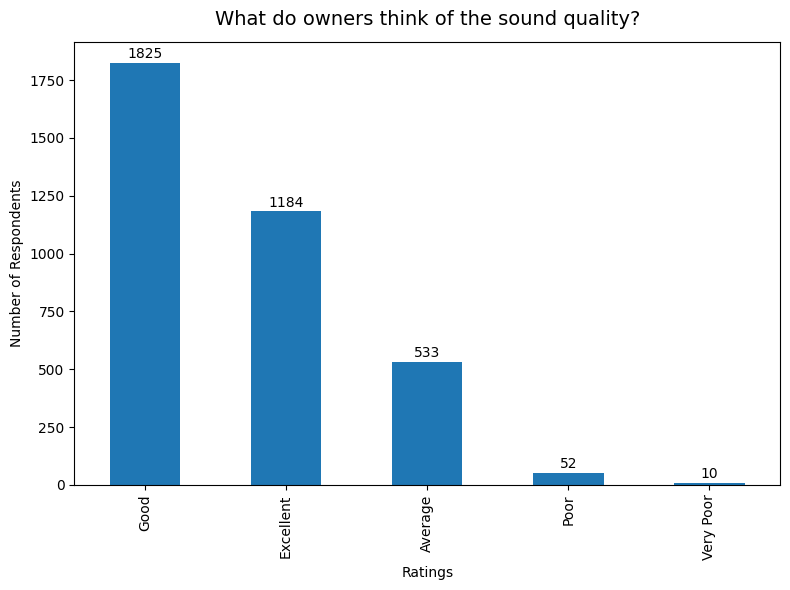

In [22]:
# How satisfied are the owners with the sound quality?

# Data
sound_quality_ratings = df_users['sound_quality_rating'].value_counts().sort_values(ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(8,6))

# Plot
sound_quality_ratings.plot(kind='bar', ax=ax)

# Labels
ax.set_title("What do owners think of the sound quality?", fontsize=14, pad=12)
ax.set_xlabel("Ratings")
ax.set_ylabel("Number of Respondents")

# Add data labels
for container in ax.containers:
    ax.bar_label(container, padding=1)

# Layout
plt.tight_layout()

plt.show()

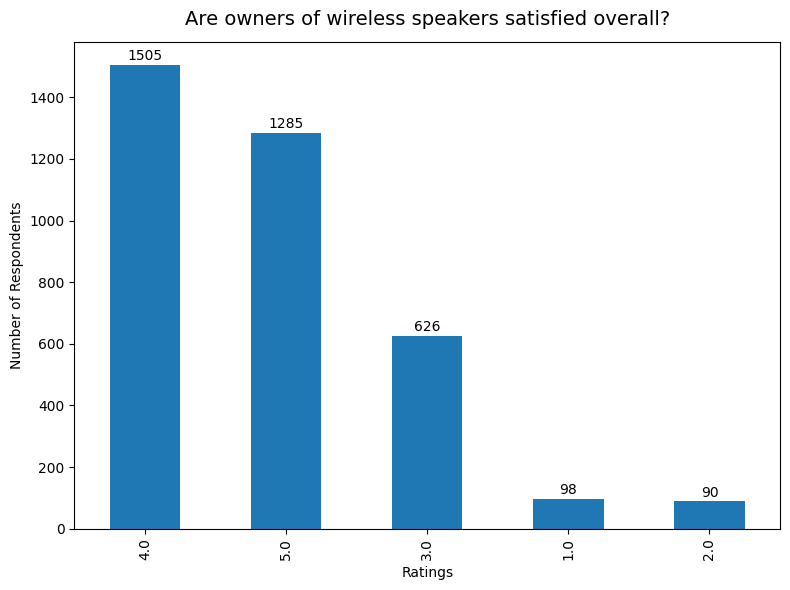

In [23]:
# How satisfied are the owners overall?

# Data
satisfaction = df_users['overall_satisfaction'].value_counts().sort_values(ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(8,6))

# Plot
satisfaction.plot(kind='bar', ax=ax)

# Labels
ax.set_title("Are owners of wireless speakers satisfied overall?", fontsize=14, pad=12)
ax.set_xlabel("Ratings")
ax.set_ylabel("Number of Respondents")

# Add data labels
for container in ax.containers:
    ax.bar_label(container, padding=1)

# Layout
plt.tight_layout()

plt.show()

In [24]:
# how much do owners spend on wireless speakers?

df_users['price_paid'].value_counts()

price_paid
$50 to $100         1253
Less than $50       1133
$100 to $200         851
$200 to $300         247
- More than $300     117
More than $300         3
Name: count, dtype: int64

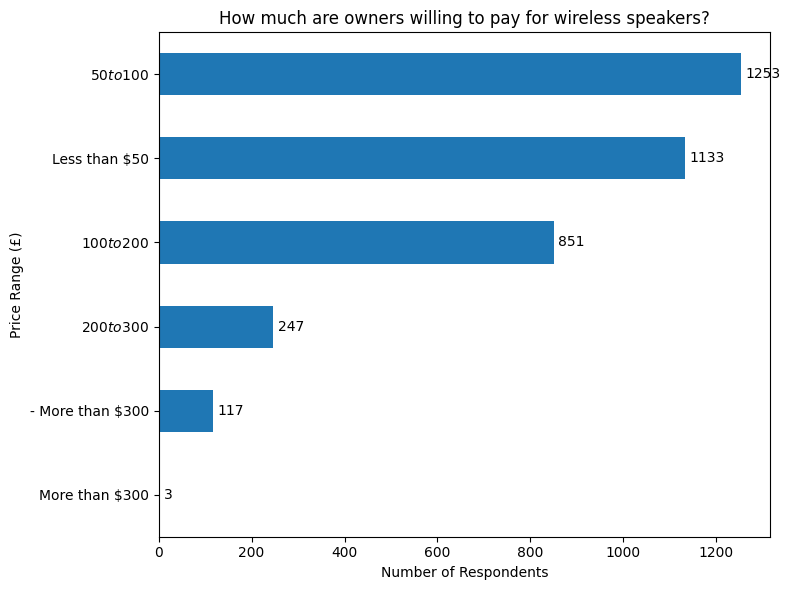

In [25]:

# Data
price = df_users['price_paid'].value_counts().sort_values(ascending=True)


# Create figure
fig, ax = plt.subplots(figsize=(8,6))


# Plot
price.plot(kind='barh', ax=ax)

# Labels
ax.set_ylabel("Price Range (£)")
ax.set_xlabel("Number of Respondents")
ax.set_title("How much are owners willing to pay for wireless speakers?")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()


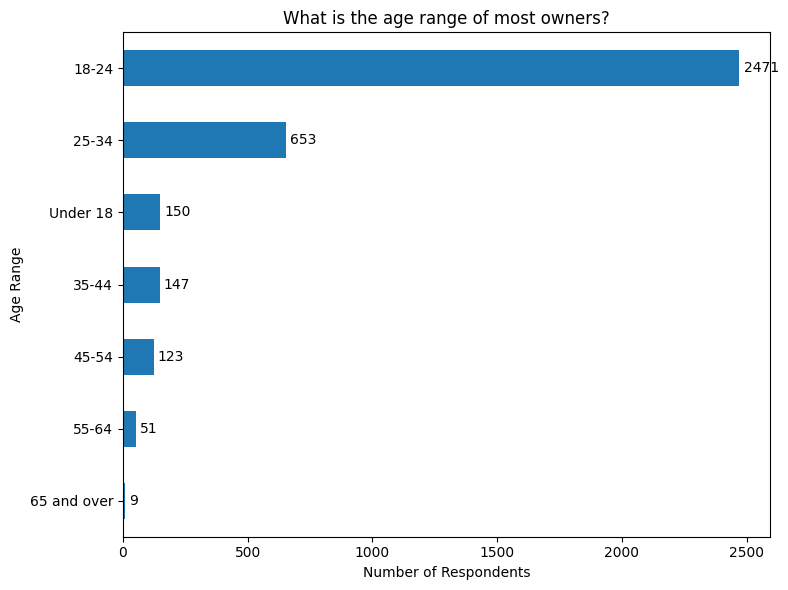

In [26]:
# Who are these owners, what age group are they?


# Data
ages = df_users['age'].value_counts().sort_values(ascending=True)


# Create figure
fig, ax = plt.subplots(figsize=(8,6))


# Plot
ages.plot(kind='barh', ax=ax)

# Labels
ax.set_ylabel("Age Range")
ax.set_xlabel("Number of Respondents")
ax.set_title("What is the age range of most owners?")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

### Qualitative Analysis

**Exploring qualitative feedback**

To understand how consumers evaluate the price of wireless speakers, open-ended responses are analysed using text mining techniques. 

The analysis follows three stages:

- Exploratory keyword analysis to identify recurring language patterns 

- Phrase analysis to capture contextual meaning  

- Topic modelling to uncover recurring theme.

In [27]:
# import the libraries for text processing

from nltk.corpus import stopwords
from collections import Counter
from nltk.util import ngrams
from wordcloud import WordCloud
from textblob import TextBlob
from nltk.tokenize import word_tokenize

nltk.download("stopwords")
nltk.download("punkt")
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADACHUKWU\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADACHUKWU\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADACHUKWU\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [28]:
# function to clean text

# Clean text
def clean_text (text):
    if pd.isna(text):
        return ""   # return empty string if null or missing values.

    text = str(text).lower() # converts to string and lower case.
    text = re.sub(r"[^a-z\s]", " ", text) # removes non letter and non space and replace with space.
    text = re.sub(r"\s+", " ", text).strip() # remove trailing white spaces.
    return text  


df_users['clean_text'] = df_users['price_evaluation'].apply(clean_text)

# Tokenise
def tokenize(text):
    return word_tokenize(text)

df_users['tokens'] = df_users["clean_text"].apply(tokenize)

# create the stopwords list
sw = set(stopwords.words("english"))
stop_keywords = {'think', 'compare', 'similar', 'bang', 'the', 'buying', 'buy', 'one', 
                   'willing', 'weather', 'tend', 'option', 'cheap', 'good', 
                   'worth', 'use', 'speakers', 'look', 'based', 'much', 'spend', 'speaker', 'would', 'expensive'}
custom_stopwords = sw.union(stop_keywords)

def remove_stopwords(tokens):
    return [word for word in tokens if word not in custom_stopwords]

df_users['clean_tokens'] = df_users['tokens'].apply(remove_stopwords)




### Keyword Overview

The word cloud provides an initial overview of frequently mentioned terms in consumer responses after removing stopwords.

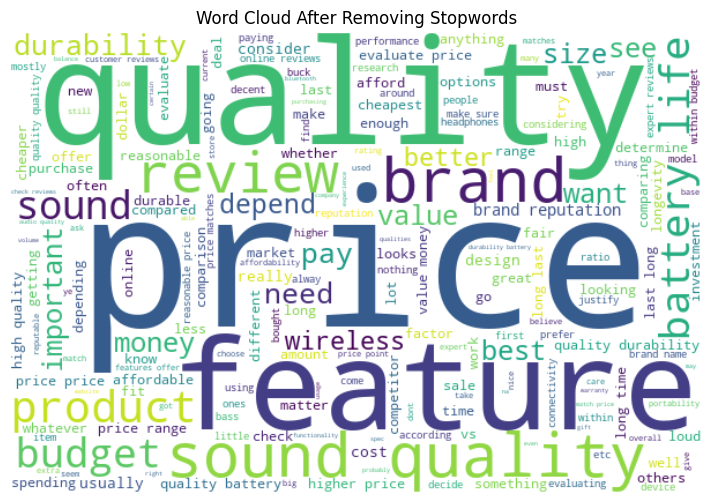

In [29]:
text_cloud = ' '.join([' '.join(tokens) for tokens in df_users["clean_tokens"]])

wordcloud = WordCloud(width=600, height=400, background_color='white').generate(text_cloud)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud After Removing Stopwords')
plt.show()

**Insights**

The word cloud shows that price, quality, feature and brand are the most dominant concepts in how owners evaluate wireless speakers, with sound quality, battery life and budget also featuring prominently.

### Most Frequently Mentioned Keywords

To quantify the patterns observed in the word cloud, the most frequently occurring keywords will be extracted from the cleaned text.

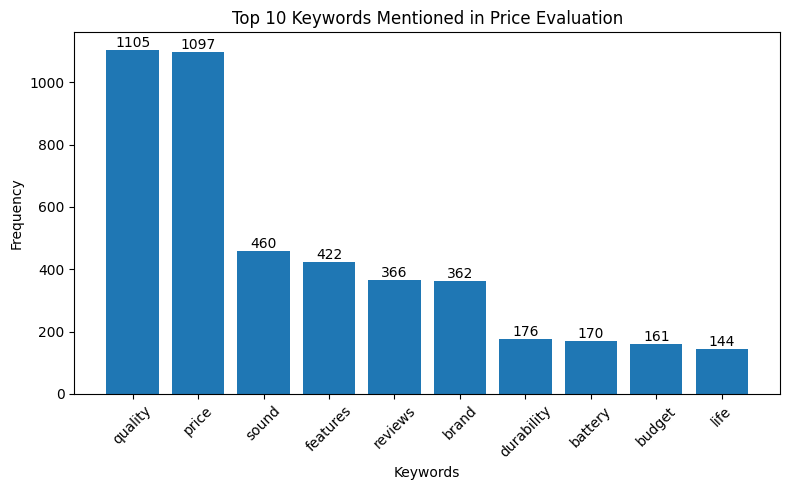

In [30]:
all_words = [word for doc in 
df_users['clean_tokens'] for word in doc]
word_counts = Counter(all_words).most_common(10)

words, counts = zip(*word_counts)

plt.figure(figsize=(8,5))
bars = plt.bar(words, counts)

plt.ylabel("Frequency")
plt.xlabel("Keywords")
plt.title("Top 10 Keywords Mentioned in Price Evaluation")
plt.xticks(rotation=45)

# Add data labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Insights**

 Top 10 keywords show that quality and price are the most dominant concepts in how owners evaluate wireless speakers, with sound, battery, features, life and budget also featuring prominently.

### Phrase Analysis (Bigram & Trigrams)

In [31]:
from nltk import bigrams, trigrams

In [32]:
bigrams = list(ngrams(all_words, 2))
trigrams = list(ngrams(all_words, 3))

bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

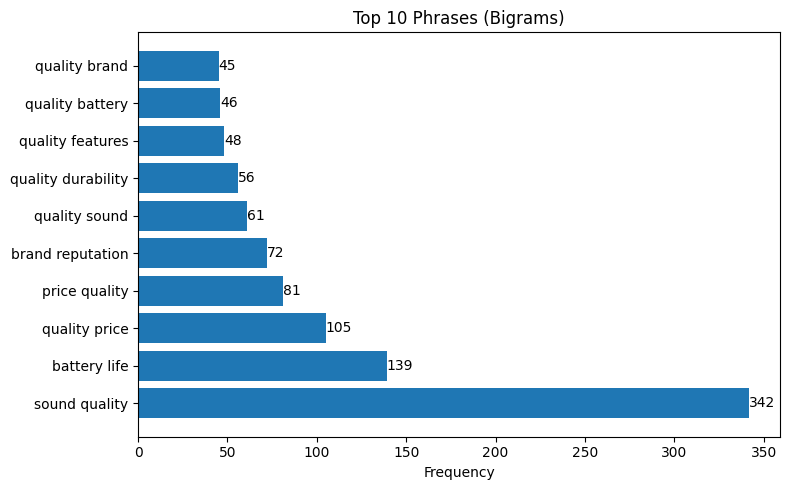

In [33]:
# visualise common phrase

common_bigrams = bigram_counts.most_common(10)

bg_labels = [' '.join(bg) for bg, count in common_bigrams]
bg_counts = [count for bg, count in common_bigrams]

plt.figure(figsize=(8,5))
bars = plt.barh(bg_labels, bg_counts)

plt.xlabel("Frequency")
plt.title("Top 10 Phrases (Bigrams)")

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{width}', va='center')


plt.tight_layout()
plt.show()

 **Insights**
 
 The distribution shows that price, quality, feature and brand are the most dominant concepts in how owners evaluate wireless speakers, with sound quality, battery life and budget also featuring prominently

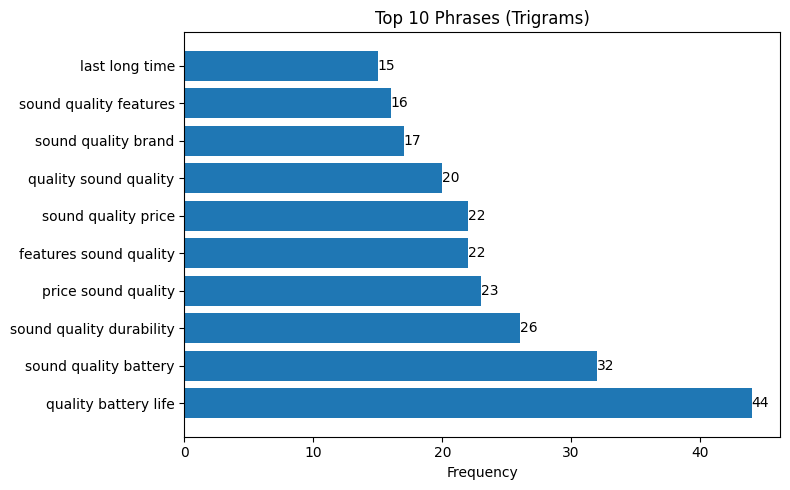

In [34]:
common_trigrams = trigram_counts.most_common(10)
tg_labels = [' '.join(tg) for tg, count in common_trigrams]
tg_counts = [count for tg, count in common_trigrams]

plt.figure(figsize=(8,5))
bars = plt.barh(tg_labels, tg_counts)

plt.xlabel("Frequency")
plt.title("Top 10 Phrases (Trigrams)")

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{width}', va='center')
plt.tight_layout()
plt.show()

 **Insights**
 
 Quality battery life, sound quality, feature and brand are the most dominant concepts.

### Thematic Analysis

#### Topic Modelling

While keyword frequency highlights commonly used terms, topic modelling helps uncover broader themes within the text.

TF-IDF vectorisation will be applied to transform the text into numerical form, followed by Non-Negative Matrix Factorisation (NMF) to extract latent topics.

In [35]:
# score each respondent review in terms of facts and opinion.

df_users['text_for_sentiment'] = df_users['clean_tokens'].apply(lambda x: ' '.join(x))

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english',  # Instantiate the model
    max_df=0.9,
    min_df=5,
    ngram_range=(1,2)
)

x_tfidf = tfidf.fit_transform(df_users['text_for_sentiment'])

In [37]:
# fit model to extract  5 top themes.

n_topics = 5

nmf = NMF(n_components=n_topics,
            random_state=42,
            max_iter=300
)

nmf.fit(x_tfidf)

,"n_components n_components: int or {'auto'} or None, default='auto'Number of components. If `None`, all features are kept.If `n_components='auto'`, the number of components is automatically inferredfrom W or H shapes... versionchanged:: 1.4 Added `'auto'` value... versionchanged:: 1.6 Default value changed from `None` to `'auto'`.",5
,"init init: {'random', 'nndsvd', 'nndsvda', 'nndsvdar', 'custom'}, default=NoneMethod used to initialize the procedure.Valid options:- `None`: 'nndsvda' if n_components <= min(n_samples, n_features), otherwise random.- `'random'`: non-negative random matrices, scaled with: `sqrt(X.mean() / n_components)`- `'nndsvd'`: Nonnegative Double Singular Value Decomposition (NNDSVD) initialization (better for sparseness)- `'nndsvda'`: NNDSVD with zeros filled with the average of X (better when sparsity is not desired)- `'nndsvdar'` NNDSVD with zeros filled with small random values (generally faster, less accurate alternative to NNDSVDa for when sparsity is not desired)- `'custom'`: Use custom matrices `W` and `H` which must both be provided... versionchanged:: 1.1 When `init=None` and n_components is less than n_samples and n_features defaults to `nndsvda` instead of `nndsvd`.",None
,"solver solver: {'cd', 'mu'}, default='cd'Numerical solver to use:- 'cd' is a Coordinate Descent solver.- 'mu' is a Multiplicative Update solver... versionadded:: 0.17 Coordinate Descent solver... versionadded:: 0.19 Multiplicative Update solver.",'cd'
,"beta_loss beta_loss: float or {'frobenius', 'kullback-leibler', 'itakura-saito'}, default='frobenius'Beta divergence to be minimized, measuring the distance between Xand the dot product WH. Note that values different from 'frobenius'(or 2) and 'kullback-leibler' (or 1) lead to significantly slowerfits. Note that for beta_loss <= 0 (or 'itakura-saito'), the inputmatrix X cannot contain zeros. Used only in 'mu' solver... versionadded:: 0.19",'frobenius'
,"tol tol: float, default=1e-4Tolerance of the stopping condition.",0.0001
,"max_iter max_iter: int, default=200Maximum number of iterations before timing out.",300
,"random_state random_state: int, RandomState instance or None, default=NoneUsed for initialisation (when ``init`` == 'nndsvdar' or'random'), and in Coordinate Descent. Pass an int for reproducibleresults across multiple function calls.See :term:`Glossary `.",42
,"alpha_W alpha_W: float, default=0.0Constant that multiplies the regularization terms of `W`. Set it to zero(default) to have no regularization on `W`... versionadded:: 1.0",0.0
,"alpha_H alpha_H: float or ""same"", default=""same""Constant that multiplies the regularization terms of `H`. Set it to zero tohave no regularization on `H`. If ""same"" (default), it takes the same value as`alpha_W`... versionadded:: 1.0",'same'
,"l1_ratio l1_ratio: float, default=0.0The regularization mixing parameter, with 0 <= l1_ratio <= 1.For l1_ratio = 0 the penalty is an elementwise L2 penalty(aka Frobenius Norm).For l1_ratio = 1 it is an elementwise L1 penalty.For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2... versionadded:: 0.17 Regularization parameter *l1_ratio* used in the Coordinate Descent solver.",0.0
,"verbose verbose: int, default=0Whether to be verbose.",0


In [38]:
# Get the vocabulary from TF-IDF
feature_names = tfidf.get_feature_names_out()

# Function to display top words for each topic
def display_topics(model, feature_names, n_top_words=10):
    """Display the top words for each topic discovered by the model."""
    
    print("="*70)
    print(f"DISCOVERED TOPICS (Top {n_top_words} keywords per topic):")
    print("="*70)
    
    for topic_idx, topic in enumerate(model.components_):
        # Get the top N words for this topic
        top_features = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"\nTopic {topic_idx + 1}: {', '.join(top_features)}")

# Display the topics
display_topics(nmf, feature_names, n_top_words=20)

DISCOVERED TOPICS (Top 20 keywords per topic):

Topic 1: quality, quality price, price quality, quality brand, quality sound, pay, quality durability, brand quality, quality features, quality product, sound quality, product, features quality, quality reviews, match, high, cheapest, high quality, cost, affordable

Topic 2: price, features, quality price, price quality, important, best, range, price range, budget, price features, wireless, reasonable, product, value, features price, affordable, brands, price important, evaluate, higher

Topic 3: reviews, online, online reviews, budget, prices, quality reviews, expert, expert reviews, check, reviews price, check reviews, customer, looking, brand reviews, customer reviews, reviews brand, reviews features, cheaper, brands, features

Topic 4: sound, sound quality, battery, life, battery life, durability, quality battery, features, quality sound, quality durability, design, size, life sound, long, brand sound, price sound, durability sound, c

### Thematic Coding Framework

Based on the topic modeling results, the following themes are defined:

- **Product Quality**
- **Budget**
- **Reviews**
- **Product Features**
- **Brand Reputation**

Using **Rule-based Coding** to systematically assign predefined thematic labels to reviews, transforming unstructured qualitative text into structured quantitative data that can be measured and compared across themes.

In [39]:
theme_codebook = {
    "Product Quality": [
        "high quality", "quality product", "quality sound", "quality brand",
        "quality durability", "quality features", "quality price", "quality reviews",
        "sound quality", "quality match", "high", "cost", "affordable", "cheapest",
        "pay", "product"
    ],

   "Budget": [
        "price range", "budget", "affordable", "reasonable", "price features",
        "price quality", "price important", "higher", "value", "best price",
        "wireless", "brands", "evaluate", "price", "important", "range"
    ], 

    "Reviews": [
        "online reviews", "expert reviews", "customer reviews", "check reviews",
        "brand reviews", "reviews brand", "reviews features", "reviews price",
        "quality reviews", "cheaper", "looking", "check", "budget",
        "prices", "brands"
    ],

    "Product Features": [
        "battery life", "sound quality", "quality durability", "quality battery",
        "quality sound", "features sound", "durability sound", "life sound",
        "brand sound", "price sound", "connectivity", "design", "size",
        "long", "consider", "durability", "battery", "features"
    ],

    "Brand Reputation": [
        "brand reputation", "reputable", "brand quality", "brand features",
        "brand sound", "brand reviews", "reviews brand", "depends brand",
        "reputation brand", "quality brand", "value", "prices",
        "depends", "product", "size", "durability", "features"
    ],

}

In [40]:
# function to apply theme code to surveys responses

def assign_themes(text, codebook):
    if not text:
        return [] # Return an empty list is text is missing.

    text = text.lower()
    matched_themes =[] # Empty list to store themes in text.

    for theme, keywords in codebook.items(): # Loop through the codebook dictionary 
        for kw in keywords: # Loop through every keyword for that theme.
            pattern = r"\b" + re.escape(kw).replace(r"\ ", r"\s+") + r"\b" 
            """Creates regex pattern to search for keywords, preventing partial matches, protect special characters & allows spacing"""
            if re.search(pattern, text): # Search for text for the keyword pattern.
                matched_themes.append(theme) # keywords are appended to the empty match_theme list
                break
    
    return matched_themes

df_users["matched_themes"] = df_users['text_for_sentiment'].apply(lambda x: assign_themes(x, theme_codebook)) # Apply function to text column

In [41]:
# Theme distributions amongst respondents

all_themes = [theme for themes_list in df_users['matched_themes'] for theme in themes_list] #flattens list of lists to extract each theme.
theme_counts = Counter(all_themes)

print("\n" + "="*50)
print("Theme Distribution:")
print("="*50)
for theme, count in theme_counts.most_common():
    print(f"{theme}: {count} reviews")


Theme Distribution:
Budget: 1414 reviews
Product Features: 1056 reviews
Brand Reputation: 1006 reviews
Product Quality: 866 reviews
Reviews: 543 reviews


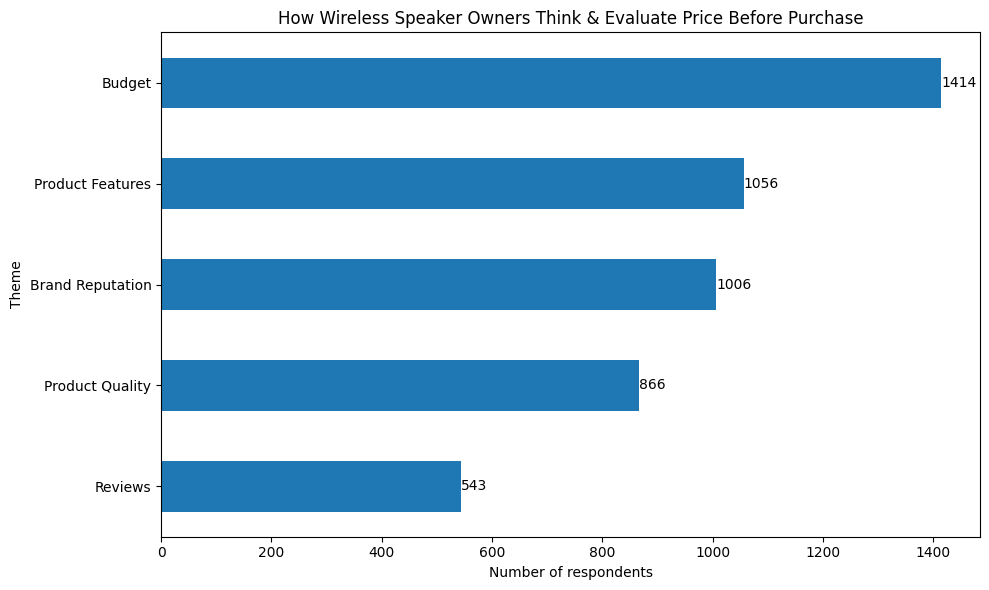

In [42]:
# Visualise the distribution 

theme_df = pd.DataFrame(theme_counts.most_common(), columns=['Theme', 'Count'])
theme_df = theme_df.sort_values('Count', ascending=True)

ax = theme_df.plot(
    x='Theme',
    y='Count',
    kind='barh',
    title='How Wireless Speaker Owners Think & Evaluate Price Before Purchase',
    xlabel='Number of respondents',
    legend=False,
    figsize=(10,6)
)

ax.bar_label(ax.containers[0], fmt="%.0f")

plt.tight_layout()
plt.show()

**Insights**

Budget is the most dominant theme, meaning the majority of owners primarily think about price and affordability when evaluating a wireless speaker purchase, followed closely by Product Features and Brand Reputation.

Reviews is the least considered theme, suggesting owners rely more on their own budget and feature assessment than on external opinions.

### Segmentation Analysis

To understand whether purchase drivers differ across groups, the extracted themes were analysed across age segments.

- What does each age group feel or consider when evaluating price of wireless speakers?

In [43]:

# Percentage of each theme by age group

segment_theme_pct = (
    df_users.explode("matched_themes")
    .groupby(["age", "matched_themes"])
    .size()
    .unstack(fill_value=0)
    .div(df_users["age"].value_counts(), axis=0)
    .mul(100)
    .round(1)
)

segment_theme_pct

matched_themes,Brand Reputation,Budget,Product Features,Product Quality,Reviews
age,,,,,
18-24,29.2,40.1,31.2,24.9,15.6
25-34,29.4,36.0,28.9,25.0,14.7
35-44,20.4,41.5,22.4,19.7,11.6
45-54,17.9,39.0,17.1,20.3,16.3
55-64,15.7,37.3,19.6,5.9,9.8
65 and over,11.1,44.4,0.0,11.1,11.1
Under 18,21.3,38.0,20.7,19.3,12.0


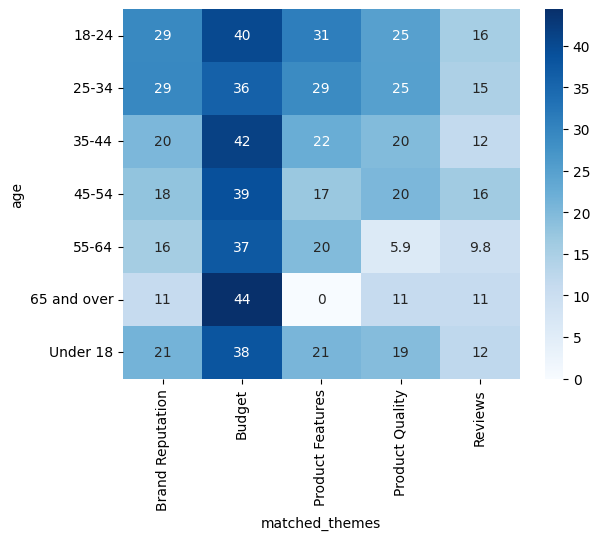

In [44]:
sns.heatmap(segment_theme_pct, annot=True, cmap="Blues")
plt.show()

**Budget dominates across all age groups** — it is consistently the highest scoring theme regardless of age, confirming price sensitivity is universal. However the intensity varies — 35-44 and 65 and over lean most heavily on budget (42% and 44%) while younger groups balance it more evenly across themes.

**Brand Reputation declines with age** — younger groups (18-24: 30%, 25-34: 30%) care more about brand than older groups (55-64: 16%, 65 and over: 11%), suggesting younger buyers are more brand conscious.

**Product Features matter most to younger and middle aged buyers** — peaking at 32% for 18-24 and dropping to 0% for 65 and over, indicating older buyers focus almost entirely on budget and ignore features.

**Reviews are consistently the least important theme across all age groups** — no group exceeds 16%, reinforcing the earlier finding that this is a self directed purchase decision.

In summary:

Budget is the universal purchase consideration across all age groups, but younger buyers (18-34) take a more balanced approach — weighing brand reputation and product features alongside price. Older buyers (55 and above) simplify their decision making, focusing almost exclusively on budget with little regard for features or reviews.